# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [1]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd

## Dataset


In [2]:
# DO NOT MODIFY
loan_data = pd.read_csv("loan_approval.csv") #was alter because jupyter files did not correspond 


## EDA
Uncomment to see desired output. Add more analysis if you like

   loan_id  no_of_dependents     education self_employed  income_annum  \
0        1                 2      Graduate            No       9600000   
1        2                 0  Not Graduate           Yes       4100000   
2        3                 3      Graduate            No       9100000   
3        4                 3      Graduate            No       8200000   
4        5                 5  Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000           8000000 

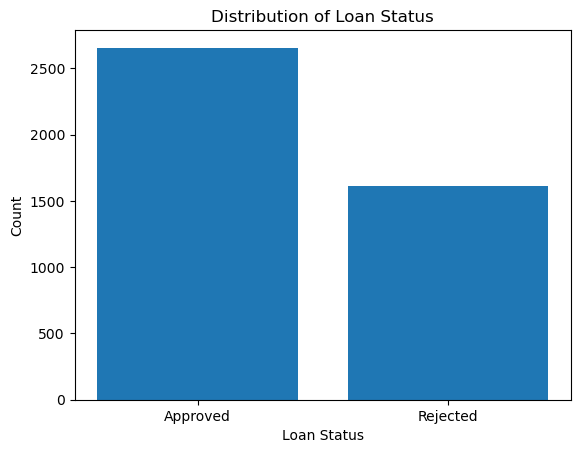

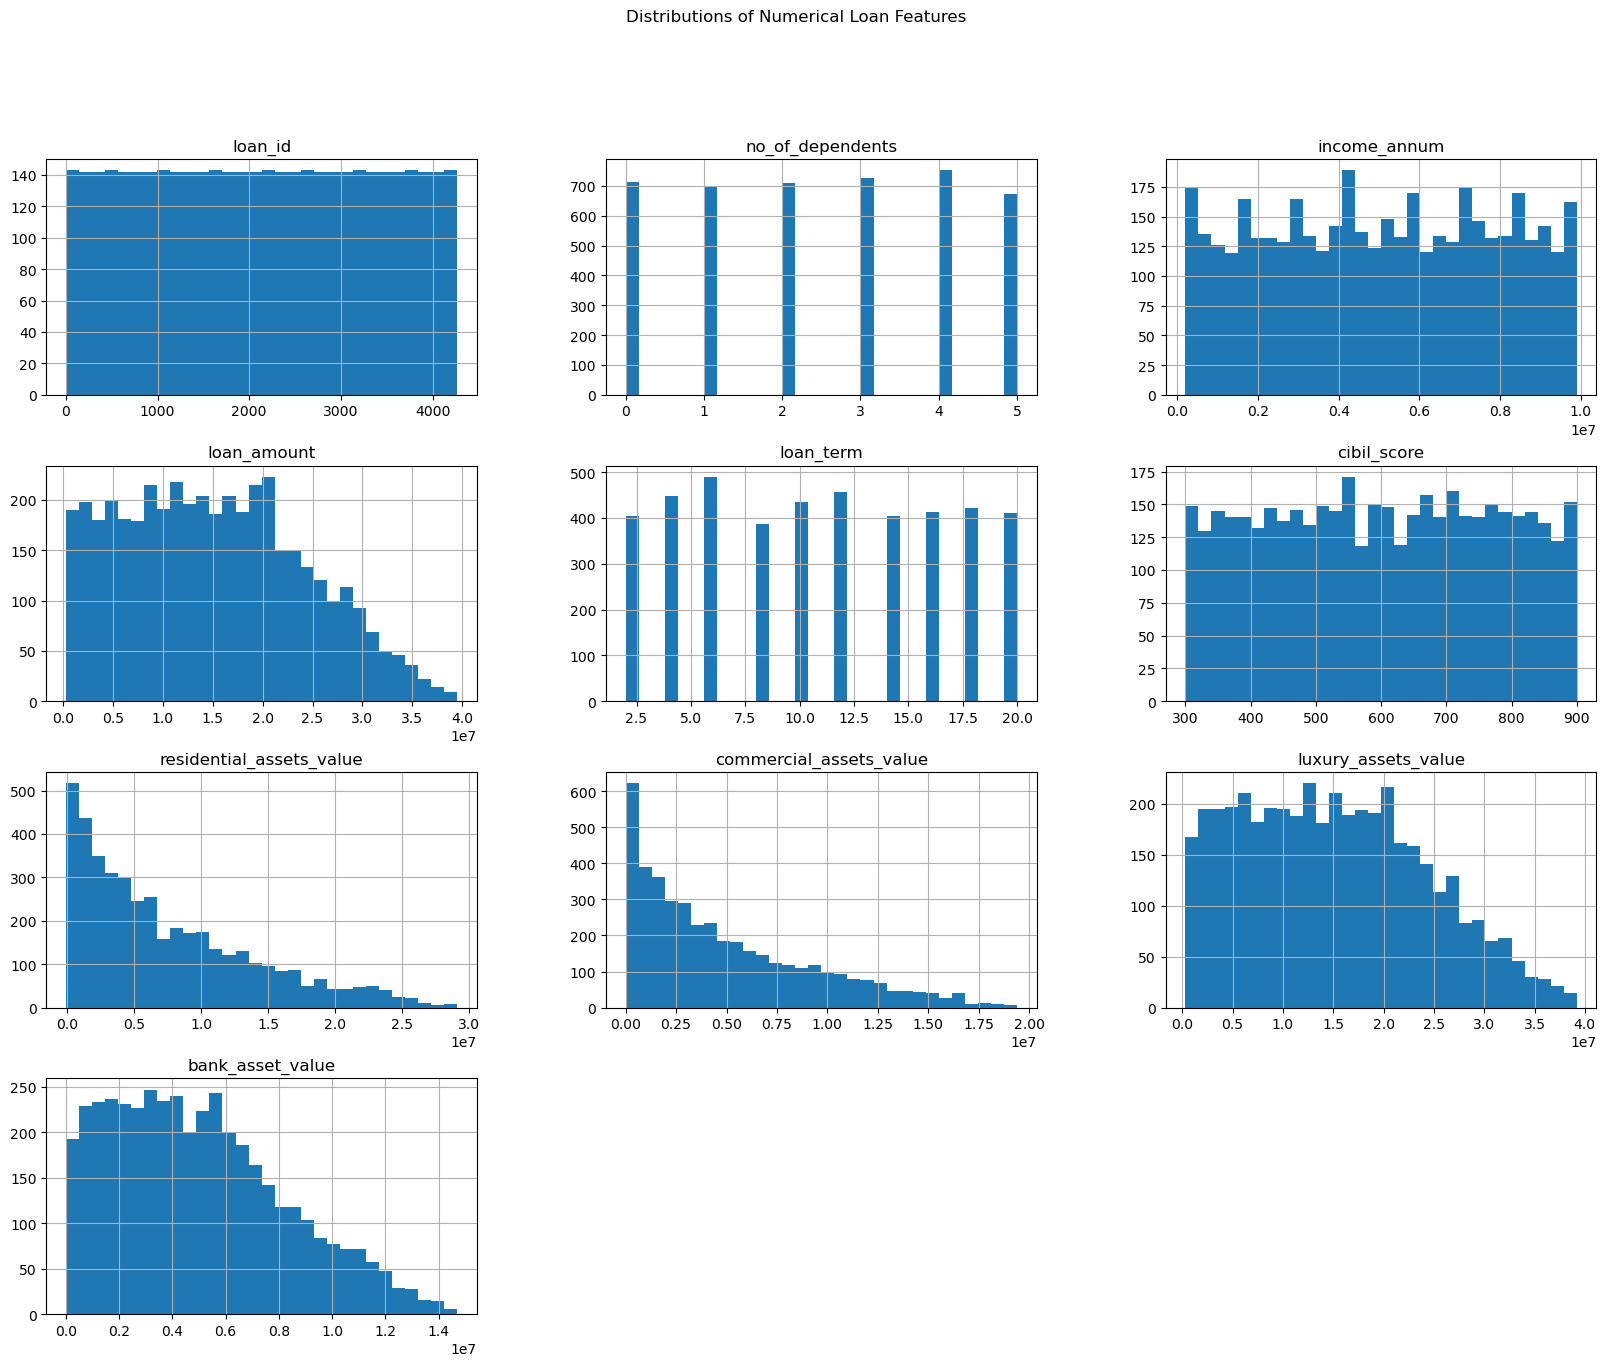

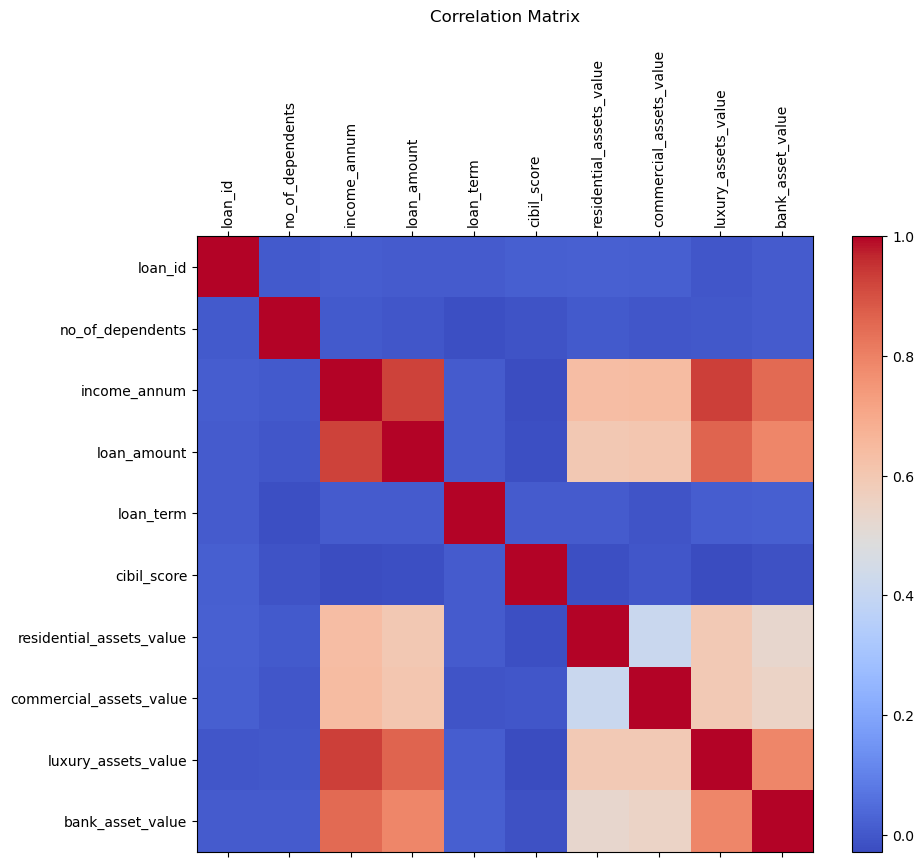

In [3]:
#comments changed because it genuinely trips with me sorry 

import matplotlib.pyplot as plt

# Display the first five rows
print(loan_data.head())

# Display column names and summary statistics 
print(loan_data.columns)
print(loan_data.describe())

# Check the data types
print(loan_data.dtypes)

# Check for missing values
print(loan_data.isnull().sum())

# Inspect category variables
print(loan_data["education"].value_counts())
print(loan_data["self_employed"].value_counts())
print(loan_data["loan_status"].value_counts()) 

# Visualize the distribution of loan status
loan_status_counts = loan_data["loan_status"].value_counts()

plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# Visualize the distributions of num feats
loan_data.hist(bins=30, figsize=(20, 15))
plt.suptitle("Distributions of Numerical Loan Features")
plt.show()

# Calculate correlations using only num columns
corr_matrix = loan_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap="coolwarm")
fig.colorbar(cax)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix", pad=20)
plt.show()

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [4]:
loan_data['education'] = loan_data['education'].map({'Graduate': 1, 'Not Graduate': 0})
# Hint: Other categorical variables are self_employed and loan_status

loan_data["self_employed"] = loan_data["self_employed"].map({
    "Yes": 1,
    "No": 0
})

loan_data["loan_status"] = loan_data["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

print(loan_data[
    ["education", "self_employed", "loan_status"]
].head())

   education  self_employed  loan_status
0          1              0            1
1          0              1            0
2          1              0            0
3          1              0            0
4          0              1            0


## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [5]:
# Import tools for splitting data and building the classifier

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Model Training and Evaluation

In [6]:
# Separate predictors from the approval outcome

X = loan_data.drop(columns=["loan_id", "loan_status"])
y = loan_data["loan_status"]

# Create training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predict loan outcomes for the testing data
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9800936768149883

Confusion Matrix:
[[314   9]
 [  8 523]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



## Model Optimization and Testing

In [7]:
from sklearn.model_selection import GridSearchCV

# Define combinations of Random Forest settings to test
parameter_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Test each combination using five-fold cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameter_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Select the best model found during cross-validation
best_model = grid_search.best_estimator_
optimized_predictions = best_model.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print(
    "Optimized accuracy:",
    accuracy_score(y_test, optimized_predictions)
)

print("\nOptimized Confusion Matrix:")
print(confusion_matrix(y_test, optimized_predictions))

print("\nOptimized Classification Report:")
print(classification_report(y_test, optimized_predictions))

Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Optimized accuracy: 0.9836065573770492

Optimized Confusion Matrix:
[[314   9]
 [  5 526]]

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

